In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn surprise torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554987 sha256=3c46f7cb83d4f5606556f17456942d02805832d9e38468ddcf8462bcde74b152
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python

# importing required library

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")
import time
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.ensemble import RandomForestClassifier

# Loading datasets

In [ ]:
ratings = pd.read_csv('/content/drive/MyDrive/ml-32m/ratings.csv')
movies = pd.read_csv('/content/drive/MyDrive/ml-32m/movies.csv')
tags = pd.read_csv('/content/drive/MyDrive/ml-32m/tags.csv')
links = pd.read_csv('/content/drive/MyDrive/ml-32m/links.csv')

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Ratings shape: (32000204, 4)
Movies shape: (87585, 3)
Tags shape: (2000072, 4)
Links shape: (87585, 3)


In [ ]:
print("Ratings Dataset")
display(ratings.head())

print("Movies Dataset")
display(movies.head())

print("Tags Dataset")
display(tags.head())

print("Links Dataset")
display(links.head())

Ratings Dataset


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


Movies Dataset


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Tags Dataset


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


Links Dataset


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


# Data info

In [ ]:
print("Ratings Info")
ratings.info()

print("\nMovies Info")
movies.info()

print("\nTags Info")
tags.info()

print("\nLinks Info")
links.info()

Ratings Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB

Movies Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB

Tags Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000072 entries, 0 to 2000071
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   userId     int64 
 1   movieId    int64 
 2   tag        object
 3   timestamp  int64 
dtypes: int64(3), object(1)
memory usage: 61.0+ MB

Links In

# Checking and handling missing value

In [ ]:
# Checking missing values
print("Missing values")
print(ratings.isnull().sum())
print(movies.isnull().sum())
print(tags.isnull().sum())

Missing values
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64


## Merge ALL datasets

In [ ]:
# Combine tags safely
tags_grouped = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x.dropna().astype(str)))
    .reset_index()
)
# Merge datasets

data = pd.merge(ratings, movies, on="movieId", how="left")
data = pd.merge(data, tags_grouped, on="movieId", how="left")
data = pd.merge(data, links, on="movieId", how="left")


# Data preprocessing

In [ ]:
# Converting timestamp
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')

# Extracting year from movie title
data['year'] = data['title'].str.extract(r'\((\d{4})\)')
data['year'] = data['year'].fillna(0).astype(int)

# Handling missing values
data['genres'] = data['genres'].fillna("Unknown")
data['tag'] = data['tag'].fillna("NoTag")

print("Processed Dataset Shape:", data.shape)

display(data.head())

Processed Dataset Shape: (32000204, 10)


,userId,movieId,rating,timestamp,title,genres,tag,imdbId,tmdbId,year
0,1,17,4.0,1999-12-03 19:24:37,Sense and Sensibility (1995),Drama|Romance,boring nothing happens 18th century classic em...,114388,4584.0,1995
1,1,25,1.0,1999-12-03 19:43:48,Leaving Las Vegas (1995),Drama|Romance,based on a book depressing drama Nicolas Cage ...,113627,451.0,1995
2,1,29,2.0,1999-11-22 00:36:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,dystopia Jean-Pierre Jeunet surreal dark fanta...,112682,902.0,1995
3,1,30,5.0,1999-12-03 19:24:37,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,cabaret diva mistress servant shanghai umbrell...,115012,37557.0,1995
4,1,32,5.0,1999-11-22 00:00:58,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,atmospheric Brad Pitt Bruce Willis design stor...,114746,63.0,1995


## Creating classification label

In [ ]:
data['label'] = data['rating'].apply(lambda x: 1 if x >= 3.5 else 0)

data_sample = data.sample(n=300000, random_state=42)

# encode users and movies
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

data_sample['user_encoded'] = user_encoder.fit_transform(data_sample['userId'])
data_sample['movie_encoded'] = movie_encoder.fit_transform(data_sample['movieId'])

# features and target
features = data_sample[['user_encoded','movie_encoded','year']]
target = data_sample['label']

# EDA and visualisation

In [ ]:
print("Total Users:", data_sample['userId'].nunique())
print("Total Movies:", data_sample['movieId'].nunique())

Total Users: 109266
Total Movies: 17302


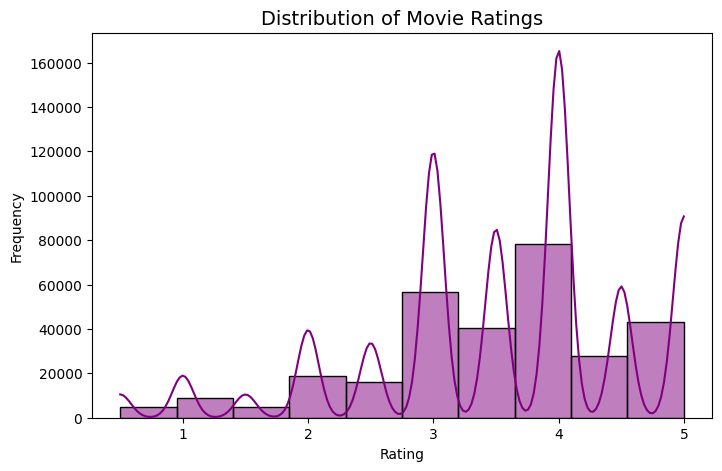

In [ ]:
# Rating distribution
plt.figure(figsize=(8,5))

sns.histplot(data_sample['rating'], bins=10, kde=True, color='purple')

plt.title("Distribution of Movie Ratings", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

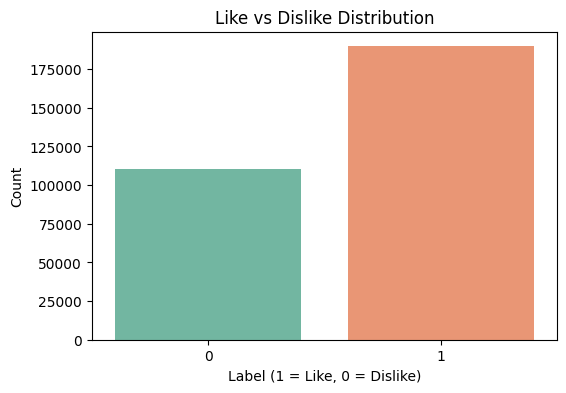

In [ ]:
# Like vs Dislike distribution
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=data_sample, palette='Set2')

plt.title("Like vs Dislike Distribution")
plt.xlabel("Label (1 = Like, 0 = Dislike)")
plt.ylabel("Count")

plt.show()

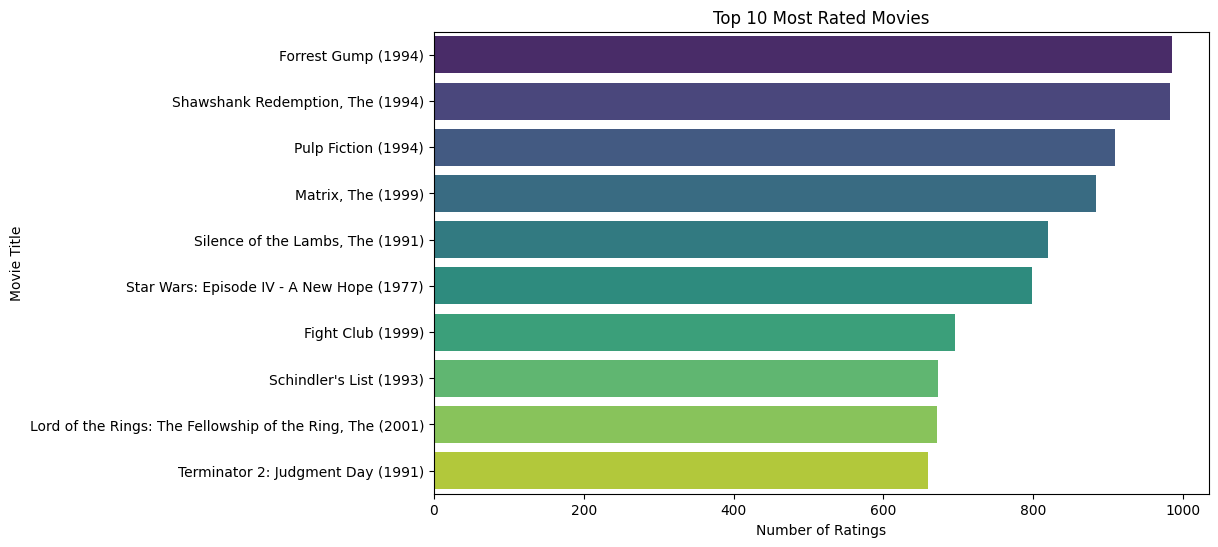

In [ ]:
# Top 10 most rated movies
top_movies = data_sample['title'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_movies.values, y=top_movies.index, palette='viridis')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")

plt.show()

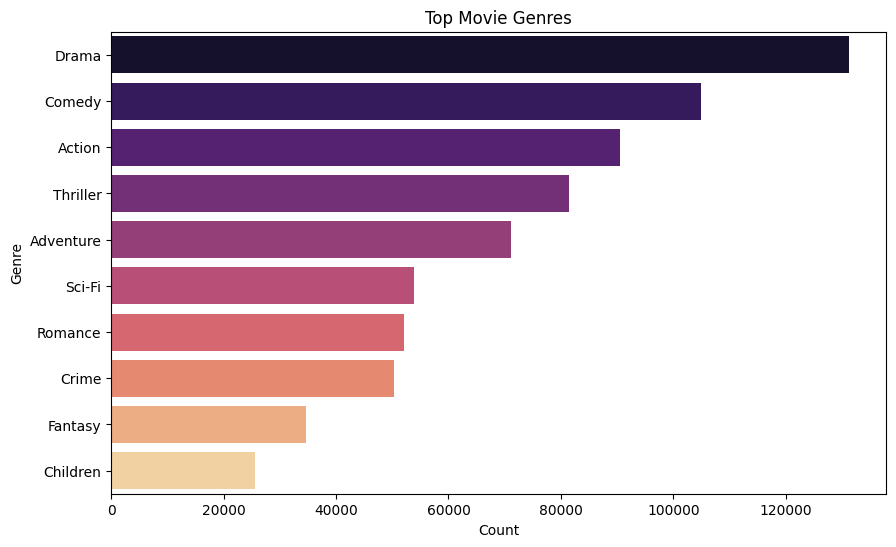

In [ ]:
# Most Popular Genres
genre_series = data_sample['genres'].str.split('|').explode()

genre_counts = genre_series.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')

plt.title("Top Movie Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

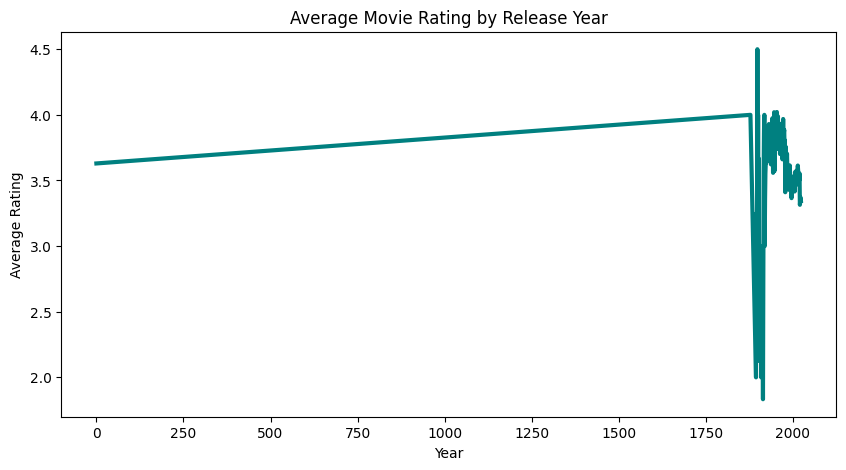

In [ ]:
# Ratings per year
ratings_by_year = data_sample.groupby('year')['rating'].mean()

plt.figure(figsize=(10,5))

ratings_by_year.plot(color='teal', linewidth=3)

plt.title("Average Movie Rating by Release Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

# Feature selection and scaling the data

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
y = target

# train test spliting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Matrix Factorization (SVD)

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split

In [ ]:
reader = Reader(rating_scale=(0.5,5))

surprise_data = Dataset.load_from_df(
    data_sample[['userId','movieId','rating']],
    reader
)

trainset, testset = surprise_split(surprise_data, test_size=0.2)

start = time.time()

svd = SVD()
svd.fit(trainset)

svd_time = time.time() - start

predictions = svd.test(testset)

svd_true = []
svd_pred = []

for p in predictions:

    true = 1 if p.r_ui >= 3.5 else 0
    pred = 1 if p.est >= 3.5 else 0

    svd_true.append(true)
    svd_pred.append(pred)

## Classification report for Matrix factorization

In [ ]:
print("Matrix Factorization Report")

print(classification_report(svd_true, svd_pred))

Matrix Factorization Report
              precision    recall  f1-score   support

           0       0.57      0.62      0.59     22070
           1       0.77      0.72      0.74     37930

    accuracy                           0.69     60000
   macro avg       0.67      0.67      0.67     60000
weighted avg       0.69      0.69      0.69     60000



## Confusion matrix for Matrix Factorization

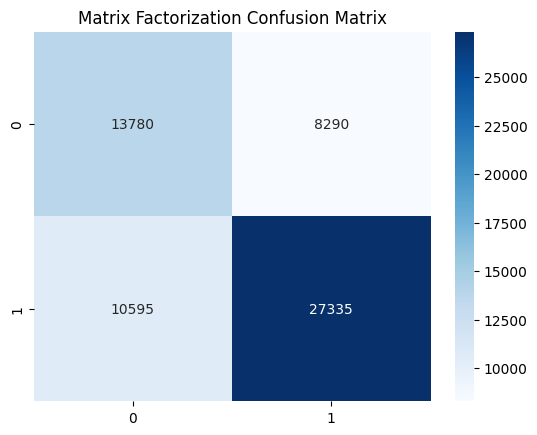

In [ ]:
cm = confusion_matrix(svd_true, svd_pred)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.title("Matrix Factorization Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

svd_scores = [p.est for p in predictions]

fpr_svd, tpr_svd, _ = roc_curve(svd_true, svd_scores)

auc_svd = roc_auc_score(svd_true, svd_scores)

print("SVD AUC:", auc_svd)

SVD AUC: 0.7310350500188086


## Hybrid Recommendation MODEL

In [ ]:
start = time.time()

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_time = time.time() - start

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

## Classification report for Hybrid model

In [ ]:
print("Hybrid Model Report")

print(classification_report(y_test, rf_pred))

Hybrid Model Report
              precision    recall  f1-score   support

           0       0.47      0.42      0.44     22157
           1       0.68      0.72      0.70     37843

    accuracy                           0.61     60000
   macro avg       0.57      0.57      0.57     60000
weighted avg       0.60      0.61      0.60     60000



## Confusion matrix for Hybrid model

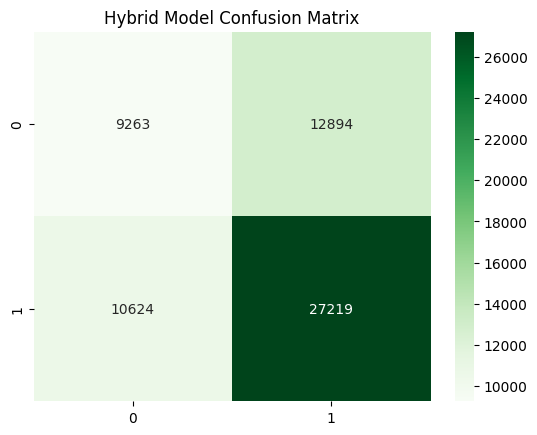

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')

plt.title("Hybrid Model Confusion Matrix")
plt.show()

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

auc_rf = roc_auc_score(y_test, rf_prob)

print("Hybrid Model AUC:", auc_rf)

Hybrid Model AUC: 0.6157335186801166


# Neural Collaborative Filtering

In [ ]:
users = torch.tensor(data_sample['user_encoded'].values)
movies_t = torch.tensor(data_sample['movie_encoded'].values)
labels = torch.tensor(data_sample['label'].values).float()

### Neural Model

In [ ]:
class NCF(nn.Module):

    def __init__(self, n_users, n_movies, emb_dim=50):
        super().__init__()

        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)

        self.fc1 = nn.Linear(emb_dim*2,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, user, movie):

        u = self.user_emb(user)
        m = self.movie_emb(movie)

        x = torch.cat([u,m],dim=1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))

        return x

## Train Model

In [ ]:
n_users = data_sample['user_encoded'].nunique()
n_movies = data_sample['movie_encoded'].nunique()

model = NCF(n_users,n_movies)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

start = time.time()

for epoch in range(5):

    optimizer.zero_grad()

    output = model(users, movies_t).squeeze()

    loss = criterion(output, labels)

    loss.backward()

    optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())

ncf_time = time.time() - start

Epoch: 0 Loss: 0.6913864612579346
Epoch: 1 Loss: 0.6836464405059814
Epoch: 2 Loss: 0.6767397522926331
Epoch: 3 Loss: 0.6707404255867004
Epoch: 4 Loss: 0.6657383441925049


## Predictions

In [ ]:
pred = model(users, movies_t).detach().numpy()

pred_class = (pred >= 0.5).astype(int)

## Classification report for Nural CF model

In [ ]:
print("Neural CF Report")

print(classification_report(labels, pred_class))

Neural CF Report
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00    110337
         1.0       0.63      1.00      0.77    189663

    accuracy                           0.63    300000
   macro avg       0.32      0.50      0.39    300000
weighted avg       0.40      0.63      0.49    300000



## Confusion matrix for Neural CF model

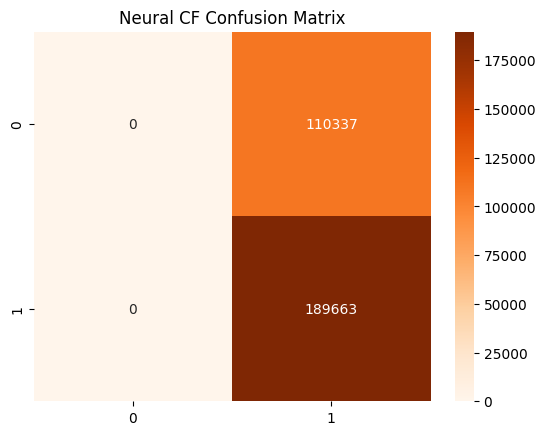

In [ ]:
cm = confusion_matrix(labels, pred_class)

sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')

plt.title("Neural CF Confusion Matrix")
plt.show()

In [32]:
pred = model(users, movies_t).detach().numpy()

ncf_scores = pred.squeeze()

true_labels = labels.detach().numpy()

from sklearn.metrics import roc_curve, roc_auc_score

fpr_ncf, tpr_ncf, _ = roc_curve(true_labels, ncf_scores)

auc_ncf = roc_auc_score(true_labels, ncf_scores)

print("Neural CF AUC:", auc_ncf)

Neural CF AUC: 0.5082147081772123


## ROC Curve Comparison

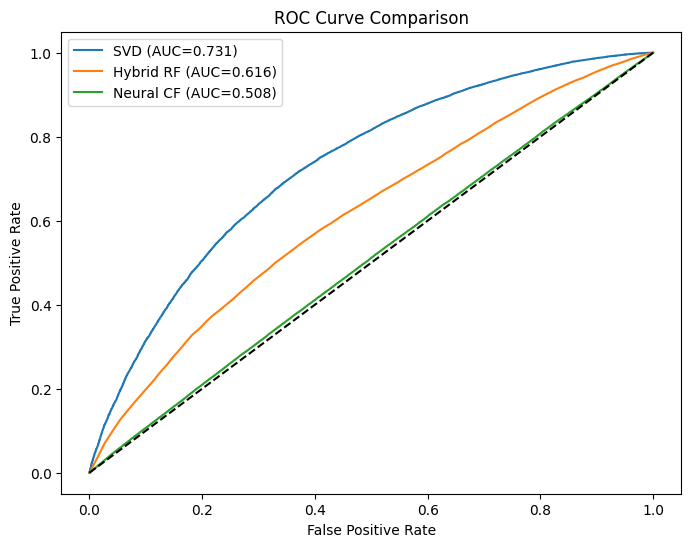

In [33]:
plt.figure(figsize=(8,6))

plt.plot(fpr_svd, tpr_svd, label=f"SVD (AUC={auc_svd:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Hybrid RF (AUC={auc_rf:.3f})")
plt.plot(fpr_ncf, tpr_ncf, label=f"Neural CF (AUC={auc_ncf:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Model Training Time Comparison

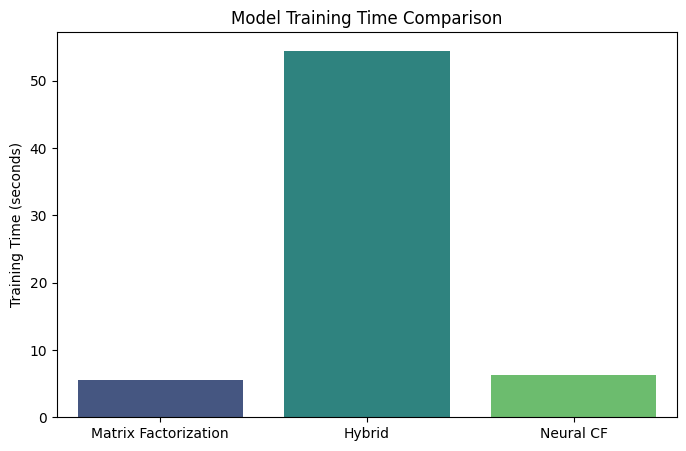

In [34]:
models = ['Matrix Factorization','Hybrid','Neural CF']

times = [svd_time, rf_time, ncf_time]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=times, palette='viridis')

plt.ylabel("Training Time (seconds)")

plt.title("Model Training Time Comparison")

plt.show()

In [35]:
results = pd.DataFrame({

    "Model": ["Matrix Factorization","Hybrid RF","Neural CF"],

    "AUC":[auc_svd, auc_rf, auc_ncf],

    "Training Time":[svd_time, rf_time, ncf_time]

})

print(results)

                  Model       AUC  Training Time
0  Matrix Factorization  0.731035       5.558465
1             Hybrid RF  0.615734      54.492575
2             Neural CF  0.508215       6.356765


# Model accuracy comparison

In [42]:
# Matrix Factorization Accuracy
svd_accuracy = accuracy_score(svd_true, svd_pred)

# Hybrid Model Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

# Neural CF Accuracy
true_labels = labels.detach().numpy()
ncf_accuracy = accuracy_score(true_labels, pred_class)

accuracy_results = pd.DataFrame({

    "Model": ["Matrix Factorization", "Hybrid Model", "Neural CF"],

    "Accuracy": [svd_accuracy, rf_accuracy, ncf_accuracy]

})

display(accuracy_results)

,Model,Accuracy
0,Matrix Factorization,0.685250
1,Hybrid Model,0.608033
2,Neural CF,0.632210


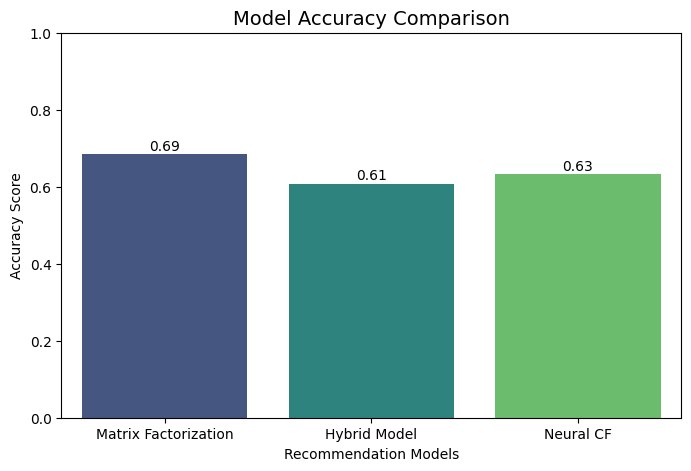

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=accuracy_results,
    palette="viridis"
)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy Score")
plt.xlabel("Recommendation Models")

plt.ylim(0,1)

for i, v in enumerate(accuracy_results["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [44]:
!pip install joblib

In [45]:
import joblib

In [46]:
model_scores = {
    "MatrixFactorization": svd_accuracy,
    "HybridModel": rf_accuracy,
    "NeuralCF": ncf_accuracy
}

best_model_name = max(model_scores, key=model_scores.get)

print("Best Model:", best_model_name)

Best Model: MatrixFactorization


In [47]:
joblib.dump(rf_model, "best_recommendation_model.pkl")

['best_recommendation_model.pkl']

In [48]:
joblib.dump(user_encoder, "user_encoder.pkl")
joblib.dump(movie_encoder, "movie_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [49]:
movies_metadata = data[['movieId','title','genres','year']].drop_duplicates()

movies_metadata.to_csv("movies_metadata.csv", index=False)

In [50]:
movie_mapping = data_sample[['movieId','movie_encoded','title']].drop_duplicates()

movie_mapping.to_csv("movie_mapping.csv", index=False)